<a href="https://colab.research.google.com/github/simranprajapati2/Microsoft-Training-2026/blob/main/DAY_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ONE DATA SET AND SELECT THE BEST ALGORITHEM DEPEND ON THE NATURE OF DATA  AND WE COMPARE 3 ALGORITHEM-LINEAR REGRESSION , SVM, RANDOM FOREST REGRESSION


In [364]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


In [365]:
data = pd.read_csv("/content/Salary_Data.csv")


In [366]:
data = data.dropna()

In [367]:
print(data.head())


    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [368]:
data.shape

(6698, 6)

In [369]:
print(data.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [370]:
X= data[["Years of Experience"]]
y = data["Salary"]

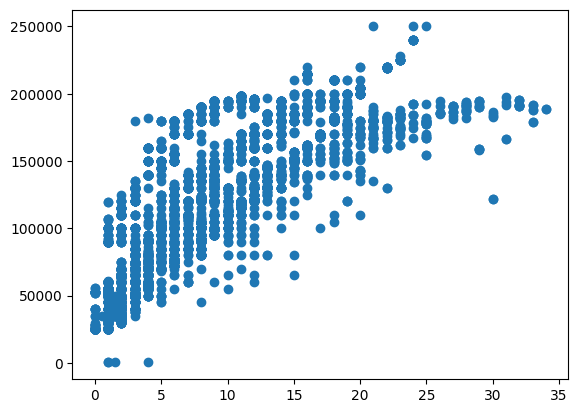

In [371]:
plt.scatter(X,y)
plt.show()

In [372]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [373]:
linear_model = LinearRegression()


In [374]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [375]:
linear_model.score(X_train,y_train)*100

65.40954906434074

In [376]:
linear_model.coef_

array([7072.86168671])

In [377]:
linear_model.intercept_

np.float64(58196.21064922571)

In [378]:
linear_pred = linear_model.predict(X_test)


In [379]:
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression R2 Score:", linear_r2)


Linear Regression R2 Score: 0.6555973709206209


In [380]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

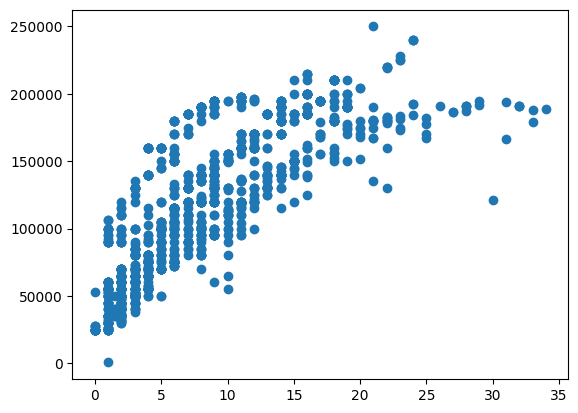

In [381]:
plt.scatter(X_test, y_test, label="Actual Salary")

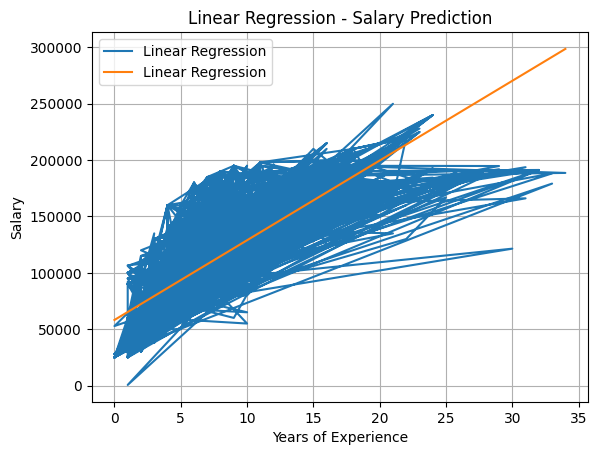

In [382]:
# Sort X values so line looks proper
sort_index = np.argsort(X_test["Years of Experience"].values)

plt.plot(X_test, y_test,
    X_test["Years of Experience"].values[sort_index],
    linear_pred[sort_index],
    label="Linear Regression"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression - Salary Prediction")
plt.legend()
plt.grid(True)

plt.show()

In [383]:

svm_model = SVR(kernel="rbf")

In [384]:
svm_model.fit(X_train, y_train)

SVR()

In [385]:

svm_pred = svm_model.predict(X_test)

In [386]:
svm_r2 = r2_score(y_test, svm_pred)

print("SVM R2 Score:", svm_r2)

SVM R2 Score: 0.03267816577363358


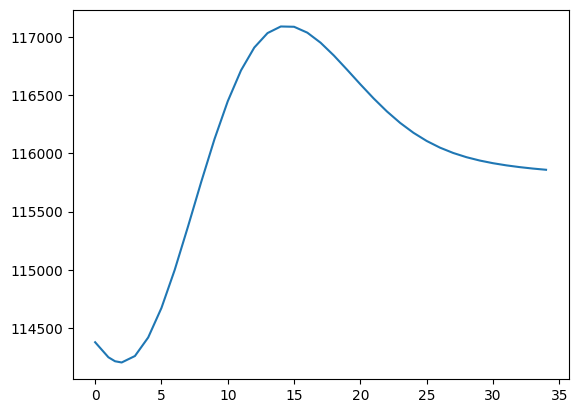

In [387]:
sort_index = np.argsort(X_test["Years of Experience"].values)
plt.plot(
    X_test["Years of Experience"].values[sort_index],
    svm_pred[sort_index],
    label="SVM Prediction"
)

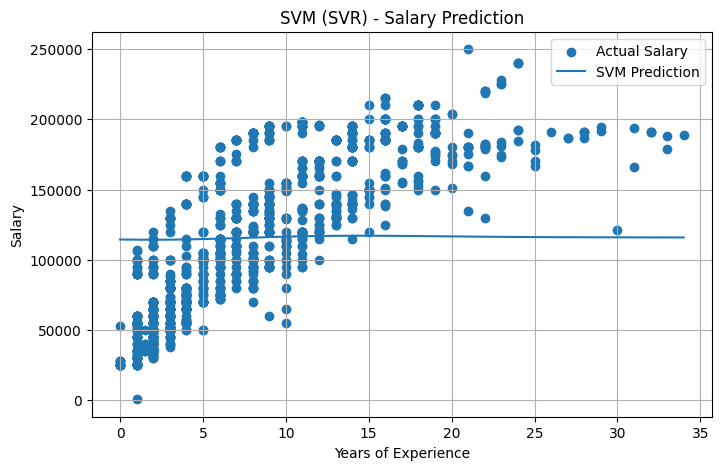

In [388]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, label="Actual Salary")

sort_index = np.argsort(X_test["Years of Experience"].values)
plt.plot(
    X_test["Years of Experience"].values[sort_index],
    svm_pred[sort_index],
    label="SVM Prediction"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("SVM (SVR) - Salary Prediction")
plt.legend()
plt.grid(True)

plt.show()

In [389]:
rf_model = RandomForestRegressor(
    n_estimators=90,
    random_state=90
)

In [390]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=90, random_state=90)

In [391]:
rf_pred = rf_model.predict(X_test)

In [392]:
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: 0.7542858782661029


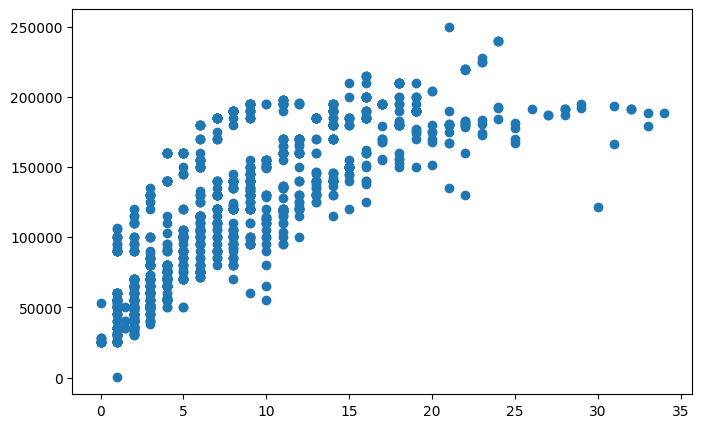

In [393]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, label="Actual Salary")

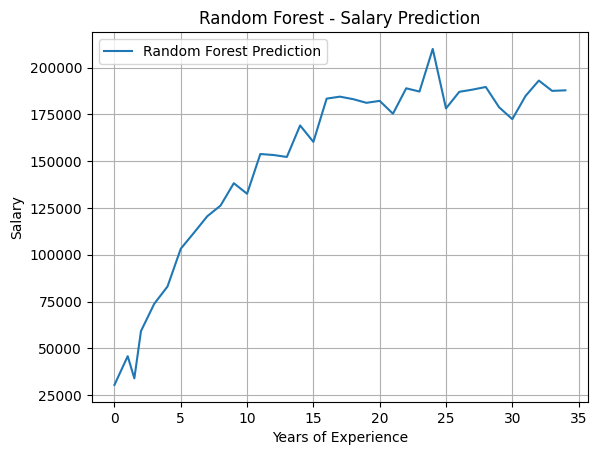

In [394]:
sort_index = np.argsort(X_test["Years of Experience"].values)

plt.plot(
    X_test["Years of Experience"].values[sort_index],
    rf_pred[sort_index],
    label="Random Forest Prediction"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Random Forest - Salary Prediction")
plt.legend()
plt.grid(True)

plt.show()



In [395]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SVM (SVR)",
        "Random Forest"
    ],
    "R2 Score": [
        linear_r2,
        svm_r2,
        rf_r2
    ],
    "Accuracy (%)": [
        linear_r2 * 100,
        svm_r2 * 100,
        rf_r2 * 100
    ]
})

In [396]:
print("\nMODEL COMPARISON")
print(comparison)



MODEL COMPARISON
               Model  R2 Score  Accuracy (%)
0  Linear Regression  0.655597     65.559737
1          SVM (SVR)  0.032678      3.267817
2      Random Forest  0.754286     75.428588


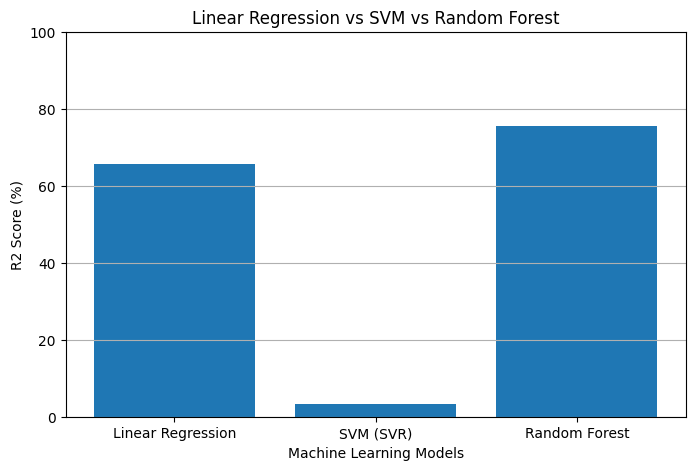

In [397]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.xlabel("Machine Learning Models")
plt.ylabel("R2 Score (%)")
plt.title("Linear Regression vs SVM vs Random Forest")

plt.ylim(0, 100)
plt.grid(axis="y")

plt.show()

In [398]:
best_model = comparison.loc[
    comparison["R2 Score"].idxmax(),
    "Model"
]

In [399]:
print("\nBest Model:", best_model)


Best Model: Random Forest


LOGISTIC REGRESSION -- Probabillity predict krta hai ,

| Algorithm             | Python Function           | Training Function            | Prediction Function     | Main Parameter         |
| --------------------- | ------------------------- | ---------------------------- | ----------------------- | ---------------------- |
| **Linear Regression** | `LinearRegression()`      | `model.fit(X_train,y_train)` | `model.predict(X_test)` | —                      |
| **SVM**               | `SVR()`                   | `model.fit(X_train,y_train)` | `model.predict(X_test)` | `kernel`, `C`, `gamma` |
| **Decision Tree**     | `DecisionTreeRegressor()` | `model.fit(X_train,y_train)` | `model.predict(X_test)` | `max_depth`            |
| **Random Forest**     | `RandomForestRegressor()` | `model.fit(X_train,y_train)` | `model.predict(X_test)` | `n_estimators`         |
| **KNN**               | `KNeighborsRegressor()`   | `model.fit(X_train,y_train)` | `model.predict(X_test)` | `n_neighbors`          |





# 📊 Regression vs Classification Evaluation Metrics

## 1️⃣ Regression Metrics

Regression mein output **continuous numerical value** hota hai.

Example:

```text
Actual Salary    = ₹50,000
Predicted Salary = ₹48,000
```

### A. MAE — Mean Absolute Error

**Formula:**

$$
MAE=\frac{1}{n}\sum |y-\hat y|
$$

Meaning: Actual aur predicted value ke beech **average absolute difference**.

👉 **Lower MAE = Better model**

```python
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
```

---

### B. MSE — Mean Squared Error

**Formula:**

$$
MSE=\frac{1}{n}\sum(y-\hat y)^2
$$

Error ko square karta hai.

👉 **Lower MSE = Better**

```python
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
```

---

### C. RMSE — Root Mean Squared Error

**Formula:**

$$
RMSE=\sqrt{MSE}
$$

MSE ka square root.

👉 **Lower RMSE = Better**

```python
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
```

---

### D. R² Score — Coefficient of Determination

Model data ko kitna explain karta hai.

👉 **Higher R² = Better**

```python
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
```

### ⭐ Regression yaad rakho:

```text
MAE   → Lower is better
MSE   → Lower is better
RMSE  → Lower is better
R²    → Higher is better
```

---

# 2️⃣ Classification Metrics

Classification mein output **class/category** hota hai.

Example:

```text
Disease / No Disease
Approved / Rejected
Yes / No
0 / 1
```

## A. Accuracy

Kitni predictions correct hain.

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
```

👉 **Higher Accuracy = Better**

---

## B. Precision

Model ne jitne **positive predict** kiye, unmein se kitne actually positive the.

$$
Precision=\frac{TP}{TP+FP}
$$

```python
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
```

---

## C. Recall

Actual positive cases mein se model ne kitne correctly identify kiye.

$$
Recall=\frac{TP}{TP+FN}
$$

```python
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
```

---

## D. F1-Score

Precision aur Recall ka balance.

$$
F1=2\times\frac{Precision\times Recall}{Precision+Recall}
$$

```python
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
```

👉 **Higher F1 = Better**

---

## E. Confusion Matrix

```python
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)
```



In [400]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor